In [ ]:
#In this project, i will perform financial forecasting using ML and DL techniques
#ML is a subfield of AI that enables machines to learn from data and improve at a given task with experience without being explicitly programmed
#DL is a subfield of ML that utilizes multi-layered artificial neural networks to solve complex problems
#predict companies 'future quarterly revenues and EPS using historical data from financial statements such as balance sheets, income statements and cash flow statements



In [5]:
!pip install pandas
!pip install scikit-learn

  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   -------- ------------------------------- 1.8/8.4 MB 9.4 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.4 MB 8.9 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.4 MB 8.8 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.4 MB 8.4 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.4 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 8.4/8.4 MB 7.5 MB/s  0:00:01
Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl (37.4 MB)

   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -------- ------------------------------- 1/5 [scipy]
   -----

In [12]:
import pandas as pd
pd.set_option('display.max_columns',250)
import warnings
warnings.filterwarnings('ignore')

In [19]:
df = pd.read_csv(r"C:\Users\shann\AppData\Local\Programs\Microsoft VS Code\financial_data.csv")
df

,Company Name,Sector,Industry,Ticker,Report Date,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last

In [20]:
#display column names
df.columns.tolist()

['Company Name',
 'Sector',
 'Industry',
 'Ticker',
 'Report Date',
 'Currency',
 'Fiscal Year',
 'Fiscal Period',
 'Publish Date',
 'Restated Date',
 'Shares (Basic)',
 'Shares (Diluted)',
 'Revenue',
 'Cost of Revenue',
 'Gross Profit',
 'Operating Expenses',
 'Selling, General & Administrative',
 'Operating Income (Loss)',
 'Non-Operating Income (Loss)',
 'Interest Expense, Net',
 'Pretax Income (Loss), Adj.',
 'Pretax Income (Loss)',
 'Income Tax (Expense) Benefit, Net',
 'Income (Loss) from Continuing Operations',
 'Net Income',
 'Net Income (Common)',
 'Net Income/Starting Line',
 'Non-Cash Items',
 'Change in Working Capital',
 'Net Cash from Operating Activities',
 'Change in Fixed Assets & Intangibles',
 'Net Cash from Investing Activities',
 'Dividends Paid',
 'Cash from (Repayment of) Debt',
 'Cash from (Repurchase of) Equity',
 'Net Cash from Financing Activities',
 'Net Change in Cash',
 'Cash, Cash Equivalents & Short Term Investments',
 'Cash & Cash Equivalents',
 'Accou

In [21]:
#number of unique stock ticker symbols available in the Pandas DataFrame
df['Ticker'].unique()

<StringArray>
['AAPL', 'UNH', 'NVDA', 'XOM', 'GE', 'COST', 'JCI', 'ICE']
Length: 8, dtype: str

In [22]:
df.describe()

,Fiscal Year,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last 3 quarters,Net Profit Margin change from last 4 quarters,Return on Equity change from last quarte

In [23]:
#lets filter out df Dataframe to only obtain Apple data 
apple_df=df[df['Ticker']=='AAPL']
apple_df

,Company Name,Sector,Industry,Ticker,Report Date,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last

In [24]:
apple_df['Revenue'].max()

np.float64(124000000000.0)

In [ ]:
#display the row containing the maximum Revenue
apple_df [apple_df['Revenue'] == apple_df['Revenue'].max()]

,Company Name,Sector,Industry,Ticker,Report Date,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last

In [26]:
#PERFORM DATA VISUALIZATION USING PLOTLY; SEABORN; MATPLOTLIB

!pip install plotly
import plotly.express as px
!pip install seaborn
import seaborn as sns
!pip install matplotlib
import matplotlib.pyplot as plt

In [28]:
# focus the analysis on predicting the % change in Quarterly EPS (Target Output) and drop the % Change in Quarterly Revenue (Target Output) column

apple_df= df.drop(columns= '% Change in Quarterly Revenue (Target Output)')
apple_df

,Company Name,Sector,Industry,Ticker,Report Date,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last

In [29]:
#plot the histogram for the target column (output) for Apple
fig=px.histogram(apple_df['% Change in Quarterly EPS (Target Output)']*100, nbins=30)
fig.update_layout({'plot_bgcolor' : 'white'})

In [31]:
#keep numeric columns for correlation computation and comput the correlation matrix
numeric_df= apple_df.select_dtypes(include='number')
correlation_matrix=numeric_df.corr()
correlation_matrix

,Fiscal Year,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last 3 quarters,Net Profit Margin change from last 4 quarters,Return on Equity change from last quarte

In [32]:
correlation_matrix[['% Change in Quarterly EPS (Target Output)']]

,% Change in Quarterly EPS (Target Output)
Fiscal Year,-0.032499
Shares (Basic),0.018590
Shares (Diluted),0.018938
Revenue,-0.017307
Cost of Revenue,0.021948
...,...
Net Debt / EBIT change from last quarter,0.000572
Net Debt / EBIT change from last 2 quarters,0.003702
Net Debt / EBIT change from last 3 quarters,-0.000007
Net Debt / EBIT change from last 4 quarters,-0.000990


In [33]:
# we can sort the correlation values in a descending order and display the top 10 positively correlated features with the output (target column)
top_positive_corr = correlation_matrix[['% Change in Quarterly EPS (Target Output)']].sort_values( '% Change in Quarterly EPS (Target Output)', ascending = False)[:10]
top_positive_corr

,% Change in Quarterly EPS (Target Output)
% Change in Quarterly EPS (Target Output),1.000000
Free Cash Flow to Net Income change from last 3 quarters,0.891755
Free Cash Flow to Net Income,0.373524
Free Cash Flow to Net Income change from last quarter,0.210627
Free Cash Flow to Net Income change from last 4 quarters,0.178186
Piotroski F-Score,0.076059
Net Cash from Investing Activities,0.073103
Net Change in Cash,0.070759
Piotroski F-Score change from last 2 quarters,0.065515
Liabilities to Equity Ratio change from last 2 quarters,0.056434


In [34]:
#same idea we can use to obtain the top 10 negatively correlated features with the output (target column)
top_negative_corr = correlation_matrix[['% Change in Quarterly EPS (Target Output)']].sort_values('% Change in Quarterly EPS (Target Output)')[:10]
top_negative_corr

,% Change in Quarterly EPS (Target Output)
EBITDA change from last 2 quarters,-0.105821
Inventories,-0.088317
Misc. Long Term Liabilities,-0.082239
Piotroski F-Score change from last 3 quarters,-0.070585
Misc. Long Term Assets,-0.069340
Goodwill,-0.065617
"Accounts Receivable, Net",-0.064984
Other Long Term Liabilities,-0.063120
Other Long Term Assets,-0.060393
Share Capital & Additional Paid-In Capital,-0.057581


In [35]:
#display the top positively and negatively correlated features with the output
apple_df[top_negative_corr.reset_index()['index'].tolist() + top_positive_corr.reset_index()['index'].tolist()]

,EBITDA change from last 2 quarters,Inventories,Misc. Long Term Liabilities,Piotroski F-Score change from last 3 quarters,Misc. Long Term Assets,Goodwill,"Accounts Receivable, Net",Other Long Term Liabilities,Other Long Term Assets,Share Capital & Additional Paid-In Capital,% Change in Quarterly EPS (Target Output),Free Cash Flow to Net Income change from last 3 quarters,Free Cash Flow to Net Income,Free Cash Flow to Net Income change from last quarter,Free Cash Flow to Net Income change from last 4 quarters,Piotroski F-Score,Net Cash from Investing Activities,Net Change in Cash,Piotroski F-Score change from last 2 quarters,Liabilities to Equity Ratio change from last 2 quarters
0,-1.171717,1.900000e+07,2.214458e+10,0.000000,4.760000e+08,2653746835,598000000,2.820000e+08,4.760000e+08,1673000000,0.083333,-2.446358,-1.34426,-0.444199,-2.010722,5.597561,10000000,-17000000,0.000000,0.070228
1,4.928571,1.100000e+07,2.214458e+10,0.000000,3.140000e+08,2653746835,466000000,2.660000e+08,3.140000e+08,1693000000,-0.424908,0.667883,1.59091,-2.183484,0.711742,5.597561,-104000000,189000000,0.000000,-0.162429
2,-0.294118,2.300000e+07,2.214458e+10,0.000000,2.020000e+08,2653746835,498000000,2.620000e+08,2.770000e+08,1706000000,0.050955,-1.369941,0.89474,-0.437592,-0.061970,5.597561,-417000000,-364000000,0.000000,-0.052283
3,-0.313253,2.600000e+07,2.214458e+10,0.000000,1.820000e+08,2653746835,644000000,2.300000e+08,2.630000e+08,1747000000,-0.200000,0.487807,-2.00000,-3.235286,-0.173075,5.597561,-825000000,-787000000,0.000000,0.045842
4,0.161987,2.458694e+09,5.009211e+09,0.003937,4.019289e+09,2221000000,834000000,2.160000e+08,3.163000e+09,3000000,0.110704,-0.351735,1.93898,-0.165632,-0.377177,6.000000,-3000000,-93000000,0.000000,-0.029288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,-0.430950,1.755300e+10,6.519400e+10,0.400000,2.592600e+10,25790000000,16283000000,6.814200e+10,7.389700e+10,34397000000,0.722192,-35.029329,-1.81002,3.514779,0.259372,7.000000,1970000000,645000000,0.400000,0.101359
458,-0.414258,5.433000e+09,5.362900e+10,-0.333333,5.260500e+10,5889000000,21803000000,5.362900e+10,5.260500e+10,62115000000,0.062301,0.044902,1.24360,-0.065405,0.186370,4.000000,4234000000,-319000000,-0.500000,0.113606
459,0.395323,2.358500e+10,2.542500e+10,0.125000,1.863200e+10,4561008893,4204509139,6.364000e+10,1.863200e+10,16018000000,0.092102,-0.350364,1.95882,-0.479093,-0.456367,9.000000,-3064000000,7787000000,0.000000,0.068986
460,0.088472,2.574000e+09,5.572000e+09,-0.142857,4.244000e+09,17725000000,5850000000,6.104000e+09,2.780300e+10,17206000000,0.958036,-0.734298,1.52507,-0.237465,-0.194674,6.000000,-256000000,-279000000,0.000000,0.144433


In [36]:
#we can re-calculate the correlation matrix to only calculate the top 10 positively and negatively correlated features
correlation_matrix = apple_df[top_negative_corr.reset_index()['index'].tolist() + 
                              top_positive_corr.reset_index()['index'].tolist()].corr()
correlation_matrix

,EBITDA change from last 2 quarters,Inventories,Misc. Long Term Liabilities,Piotroski F-Score change from last 3 quarters,Misc. Long Term Assets,Goodwill,"Accounts Receivable, Net",Other Long Term Liabilities,Other Long Term Assets,Share Capital & Additional Paid-In Capital,% Change in Quarterly EPS (Target Output),Free Cash Flow to Net Income change from last 3 quarters,Free Cash Flow to Net Income,Free Cash Flow to Net Income change from last quarter,Free Cash Flow to Net Income change from last 4 quarters,Piotroski F-Score,Net Cash from Investing Activities,Net Change in Cash,Piotroski F-Score change from last 2 quarters,Liabilities to Equity Ratio change from last 2 quarters
EBITDA change from last 2 quarters,1.000000,-0.014214,-0.044133,0.045145,-0.038096,-0.026015,-0.006451,-0.063777,-0.070411,0.012340,-0.105821,0.010328,0.075518,-0.004472,-0.040545,0.061826,-0.047330,-0.036599,0.044243,-0.029718
Inventories,-0.014214,1.000000,0.631123,0.027509,0.535717,0.347902,0.448728,0.796115,0.461609,0.448792,-0.088317,-0.088826,-0.022315,0.048210,0.005725,-0.011701,0.102496,-0.107101,0.015513,-0.055452
Misc. Long Term Liabilities,-0.044133,0.631123,1.000000,-0.021898,0.935416,0.629088,0.820102,0.898575,0.824471,0.772825,-0.082239,-0.098033,-0.047890,0.041353,0.016764,0.021246,0.269030,-0.046876,-0.008386,-0.002163
Piotroski F-Score change from last 3 quarters,0.045145,0.027509,-0.021898,1.000000,-0.009108,-0.024048,0.006091,-0.012091,-0.012767,0.003946,-0.070585,-0.050511,0.013806,0.023387,-0.005564,0.525445,0.027211,-0.038934,0.416005,-0.061578
Misc. Long Term Assets,-0.038096,0.535717,0.935416,-0.009108,1.000000,0.650513,0.769038,0.810351,0.828573,0.729694,-0.069340,-0.087026,-0.043046,0.019146,0.014334,0.069657,0.283061,-0.038347,0.002772,-0.009612
Goodwill,-0.026015,0.347902,0.629088,-0.024048,0.650513,1.000000,0.672668,0.494902,0.863551,0.311440,-0.065617,-0.072923,-0.053873,0.059911,0.044133,0.036341,0.244029,-0.032171,-0.003884,-0.059052
"Accounts Receivable, Net",-0.006451,0.448728,0.820102,0.006091,0.769038,0.672668,1.000000,0.705911,0.779280,0.830082,-0.064984,-0.093505,-0.105005,0.043139,0.043481,0.032428,0.125024,-0.075205,0.022081,0.064240
Other Long Term Liabilities,-0.063777,0.796115,0.898575,-0.012091,0.810351,0.494902,0.705911,1.000000,0.730155,0.680133,-0.063120,-0.075125,-0.002274,0.022544,0.010353,0.013383,0.146920,-0.051539,0.000915,-0.024286
Other Long Term Assets,-0.070411,0.461609,0.824471,-0.012767,0.828573,0.863551,0.779280,0.730155,1.000000,0.560273,-0.060393,-0.089551,-0.114427,0.041087,0.050106,0.044125,0.324156,-0.039858,0.013631,-0.032589
Share Capital & Additional Paid-In Capital,0.012340,0.448792,0.772825,0.003946,0.729694,0.311440,0.830082,0.680133,0.560273,1.000000,-0.057581,-0.081515,-0.092299,0.039209,0.016089,0.027648,0.146240,-0.047249,0.002623,0.081902


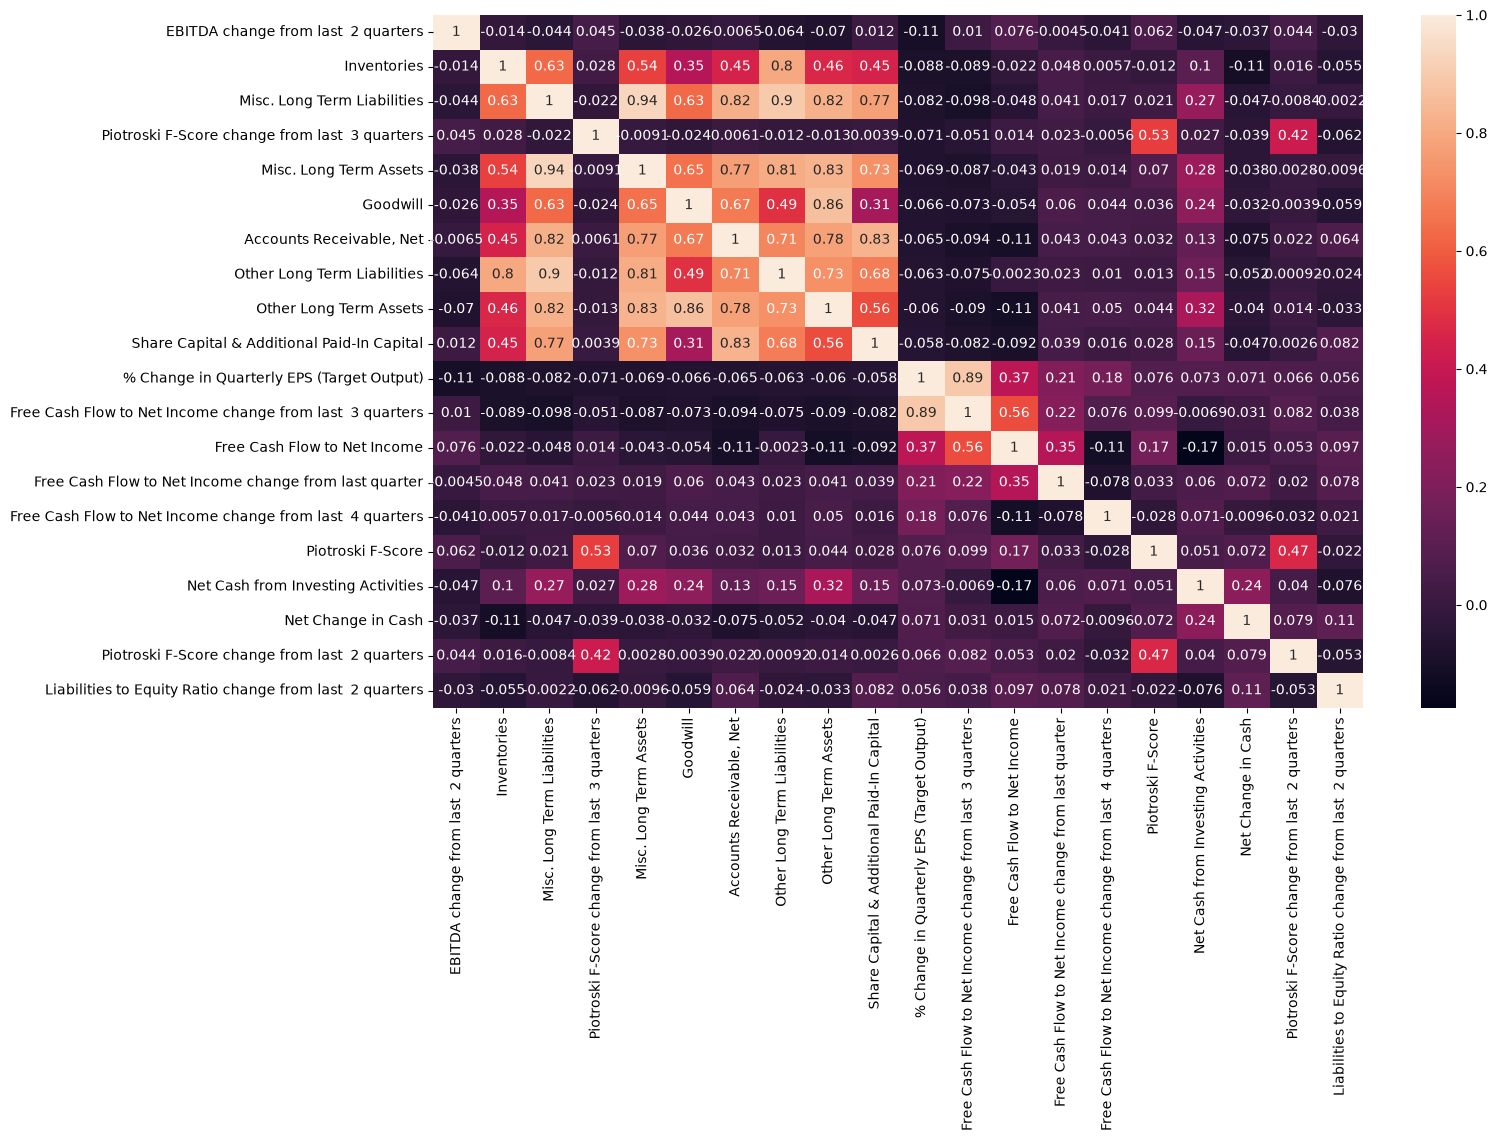

In [37]:
#use Seaborn to display a heatmap for the correlation matrix
f, ax = plt.subplots(figsize = (15, 9))
sns.heatmap(correlation_matrix, annot = True);

In [38]:
#PRACTICE OPPORTUNITY SOLUTION:**
#Write a Python code that performs the following tasks:**
#Filter out the Pandas DataFrame df to only contain rows pertaining to Nvidia corporation (Ticker Symbol: NVDA)**
#Display the histogram for the output column "% Change in Quarterly EPS (Target Output)" for Nvidia corporation using 100 bins**

nvidia_df= df[df['Ticker']=='NVDA']
nvidia_df
fig = px.histogram(nvidia_df['% Change in Quarterly EPS (Target Output)']*100, nbins=100)
fig.update_layout({'plot_bgcolor':'white'})



In [39]:
#PERFORM ONE HOT ENCODING
apple_df.info(200)

<class 'pandas.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 201 columns):
 #    Column                                                        Dtype  
---   ------                                                        -----  
 0    Company Name                                                  str    
 1    Sector                                                        str    
 2    Industry                                                      str    
 3    Ticker                                                        str    
 4    Report Date                                                   str    
 5    Currency                                                      str    
 6    Fiscal Year                                                   int64  
 7    Fiscal Period                                                 str    
 8    Publish Date                                                  str    
 9    Restated Date                                                 s

In [40]:
#convert 'Publish Date' column to datetime
apple_df['Publish Date']= pd.to_datetime(apple_df['Publish Date'])
apple_df.info(200)

<class 'pandas.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 201 columns):
 #    Column                                                        Dtype         
---   ------                                                        -----         
 0    Company Name                                                  str           
 1    Sector                                                        str           
 2    Industry                                                      str           
 3    Ticker                                                        str           
 4    Report Date                                                   str           
 5    Currency                                                      str           
 6    Fiscal Year                                                   int64         
 7    Fiscal Period                                                 str           
 8    Publish Date                                                  datetim

In [41]:
#sort the DataFrame in an ascending order based on 'Publish Date' column

apple_df.sort_values(by='Publish Date', ascending= True, inplace=True)
apple_df

,Company Name,Sector,Industry,Ticker,Report Date,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last

In [42]:
#drops some columns from the Pandas DataFrame
cols_to_drop = ['Ticker','Sector', 'Industry','Company Name', 'Report Date', 'Currency',
                'Fiscal Year', 'Publish Date', 'Restated Date']

apple_df = apple_df.drop(columns = cols_to_drop)
apple_df

,Fiscal Period,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last 3 quarters,Net Profit Margin change from last 4 quarters,Return on Equity change from last quar

In [43]:
# Let's display the original "Fiscal Period" column
print(apple_df['Fiscal Period'])

# Let's display the one-hot encoded version of the "Fiscal Period" column
fiscal_encoded = pd.get_dummies(apple_df['Fiscal Period'])
fiscal_encoded

0      Q3
1      Q4
2      Q1
3      Q2
4      Q1
       ..
455    Q2
459    Q2
460    Q3
456    Q2
461    Q2
Name: Fiscal Period, Length: 462, dtype: str


,Q1,Q2,Q3,Q4
0,False,False,True,False
1,False,False,False,True
2,True,False,False,False
3,False,True,False,False
4,True,False,False,False
...,...,...,...,...
455,False,True,False,False
459,False,True,False,False
460,False,False,True,False
456,False,True,False,False


In [44]:
# Drop the 'Fiscal Period' column from the Pandas DataFrame
apple_df = apple_df.drop('Fiscal Period', axis = 1)

# Concatenate the original DataFrame and the one-hot encoded "Fiscal Period" column
apple_df = pd.concat([apple_df, fiscal_encoded], axis = 1)
apple_df

,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last 3 quarters,Net Profit Margin change from last 4 quarters,Return on Equity change from last quarter,Return on 

In [46]:
#PRACTICE OPPORTUNITY SOLUTION:**
#Write a Python code that performs the following tasks:**
#Read the "financial_data.csv" file using Pandas and place the result in a Pandas DataFrame titled "df"** 
#Filter "df" Pandas DataFrame to only include General Electric data (Ticker Symbol: GE), and place the results in a Pandas DataFrame titled "general_electric_df"**
#Perform one-hot encoding to the "Fiscal Period" column in "general_electric_df" DataFrame using Pandas pd.get_dummies() function**
#Drop the "Fiscal Period" column from "general_electric_df" DataFrame and concatenate the one-hot encoded data**

df = pd.read_csv(r"C:\Users\shann\AppData\Local\Programs\Microsoft VS Code\financial_data.csv")
df

,Company Name,Sector,Industry,Ticker,Report Date,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last

In [ ]:
#filter out the dataframe to only select GE data
general_electric_df = df[ df['Ticker'] == 'GE' ]
general_electric_df

,Company Name,Sector,Industry,Ticker,Report Date,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last

In [ ]:
#display the one-hot encoded version of the 'Fiscal Period' column
fiscal_encoded = pd.get_dummies(general_electric_df['Fiscal Period'])
fiscal_encoded
#concatenate the original DataFrame and the one-hot encoded 'Fiscal Period' column
general_electric_df=general_electric_df.drop('Fiscal Period', axis=1)
general_electric_df = pd.concat([general_electric_df, fiscal_encoded], axis = 1)
general_electric_df


,Company Name,Sector,Industry,Ticker,Report Date,Currency,Fiscal Year,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last 3 quarters,Ne

In [57]:
#SPLIT THE DATA INTO TRAINING AND TESTING

#Dataset is split into 3 subsets
    #1 Training subset= used to train the model
    #2 validation (cross validation) subset= used to tune the model hyperparameters and to evaluate the training process quality as training proceeds
    #3 Testing (holdout) subset= used to evaluate the final performance of the trained model. Testing subset has never been seen by the model during training

#DATA SPLIT USING SCIKIT-LEARN

#using Train_test_split() function is used to split arrays or matrices into train and test subtest

#IMPORT THE FUNCTION SYNTAX
    # from sklearn.model_selection import train_test_split

#SYNTAX
#X_train,X_test,y_trian,Y_test = train_test_split(X,y, test_size=0.2, shuffle=False)

# Split the data into inputs "X" and outputs "y"
X = apple_df.drop('% Change in Quarterly EPS (Target Output)', axis = 1)
y = apple_df['% Change in Quarterly EPS (Target Output)']

In [58]:
X

,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last 3 quarters,Net Profit Margin change from last 4 quarters,Return on Equity change from last quarter,Return on 

In [59]:
y

0      0.083333
1     -0.424908
2      0.050955
3     -0.200000
4      0.110704
         ...   
455    0.041391
459    0.092102
460    0.958036
456   -1.344141
461    0.041570
Name: % Change in Quarterly EPS (Target Output), Length: 462, dtype: float64

In [61]:
# Let's perform data train/test split
# Shuffling means randomly reordering the elements in the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, shuffle = False)

print(X_train.shape, X_test.shape)

(323, 194) (139, 194)


In [62]:
print(y_train.shape, y_test.shape)

(323,) (139,)


In [63]:
X_train

,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last 3 quarters,Net Profit Margin change from last 4 quarters,Return on Equity change from last quarter,Return on 

In [65]:
#PRACTICE OPPORTUNITY SOLUTION:** 
# Using Scikit-Learn Library, split the data into 30% for testing and 70% for training** 
#Perform a sanity check by obtaining the shape of the training and testing dataset**
#Enable shuffling and rerun the code. Comment on your results.**

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, shuffle = True)
print(X_train.shape, X_test.shape)

(323, 194) (139, 194)


In [66]:
print(y_train.shape, y_test.shape)

(323,) (139,)


In [67]:
X_train

,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last 3 quarters,Net Profit Margin change from last 4 quarters,Return on Equity change from last quarter,Return on 

In [68]:
X_test

,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last 3 quarters,Net Profit Margin change from last 4 quarters,Return on Equity change from last quarter,Return on 

In [69]:
#TRIAN AND EVALUATE A LINEAR REGRESSION MODEL

#we learn about
    #1 Simple linear Regression
        #here, we predict the value of one variable Y based on independent variable X. it is simple and examine the relationship between 2 variables only

    #2 Multiple Linear Regression
        #examines the relationship between more than 2 variables. each independent variable has its own corresponding coefficient

    #3 Least Square Method
        #to estimate the coefficients of a linear regression method with the goal to find the best-fit line through a set of data points. The Regression coefficients are chosen to minimize the Residual Sum of Squares (RSS)

# Import linear_model from Scikit-Learn Library 
from sklearn import linear_model

# Train a linear regression model using Scikit-Learn Library
# First we instantiate an object out of our linear_model class
# Then we apply the fit() method to fit the model to the training dataset (X_train, y_trian)
linear_regression_model = linear_model.LinearRegression()
linear_regression_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](194,)","[-0., 0., 0.,..., 0.,-0., 0.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](194,)","['Shares (Basic)','Shares (Diluted)','Revenue',...,'Q2','Q3','Q4']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.009896
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,194
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(56)


In [72]:
#after the regression model is trained, I can evaluate its performance on the testing dataset. but the testing dataset has never been seen by the model during training
#I can compare y_predict vs the actual output y_test
y_predict= linear_regression_model.predict(X_test)

In [73]:
# Let's generate various regression metrics by comparing "y_predict" to actual outputs "y_test" (ground truth data)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np 

RMSE = float(np.sqrt(mean_squared_error(y_test, y_predict)))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)

print('Root Mean Squared Error (RMSE) =', RMSE, '\nMean Squared Error (MSE) =', MSE, '\nMean Absolute Error (MAE) =', MAE) 

Root Mean Squared Error (RMSE) = 15.02033218524683 
Mean Squared Error (MSE) = 225.6103789551618 
Mean Absolute Error (MAE) = 4.136658680500139


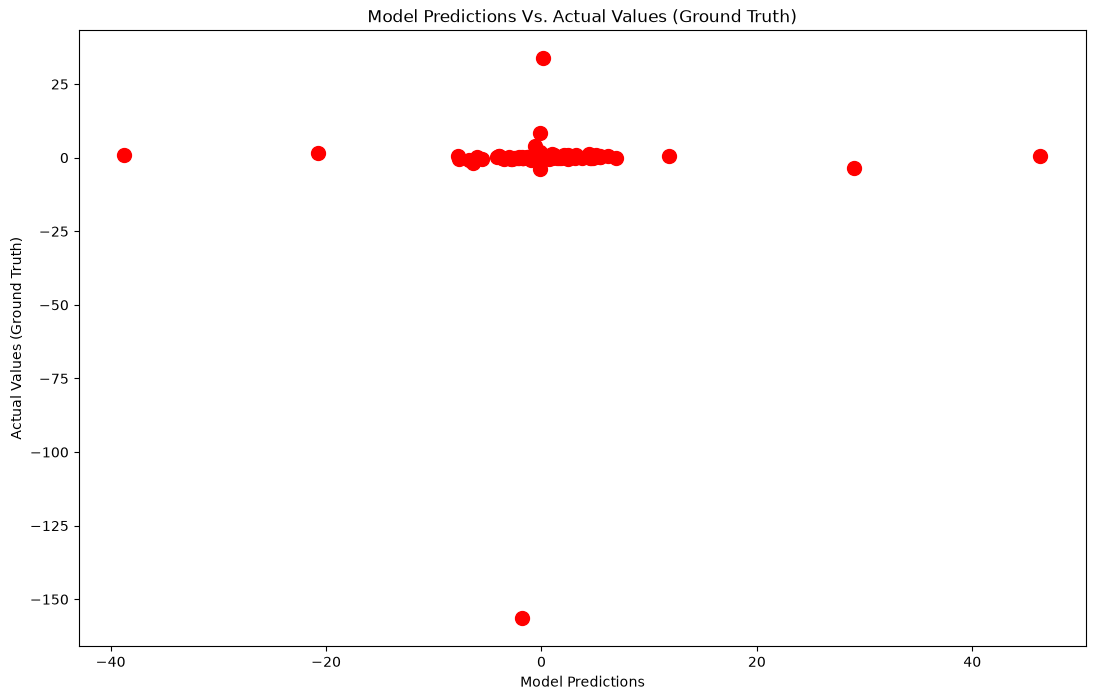

In [74]:
# Plot model predictions "y_predict" vs. actual outputs "y_test" (ground truth data)
plt.figure(figsize = (13, 8))
plt.plot(y_predict, y_test, 'o', color = 'r', markersize = 10)
plt.xlabel('Model Predictions')
plt.ylabel('Actual Values (Ground Truth)')
plt.title('Model Predictions Vs. Actual Values (Ground Truth)');

In [75]:
# Display the trained model Y-intercept
print(linear_regression_model.intercept_)

# Display the estimated coefficients for the linear regression problem
print(linear_regression_model.coef_)

-0.009895960981235796
[-2.72343447e-09  2.48894630e-09  3.57692013e-09  3.64460216e-09
 -2.38015507e-09  1.14503318e-09 -1.51790346e-10 -1.23512189e-09
 -1.24947905e-10  1.36712463e-09 -1.36006980e-09  7.67715589e-10
 -3.60771404e-10  4.06944185e-10  5.31992084e-08 -5.39046500e-08
  7.34014761e-10 -1.64916793e-10 -1.03053312e-10  2.22903958e-10
 -2.52000268e-10  1.76860309e-12 -6.55399626e-10  2.61645321e-10
 -6.60679429e-11 -2.56062208e-10  2.37837071e-10 -2.22496152e-10
  4.58174796e-12 -1.91780648e-10  3.24613160e-10  4.04889606e-11
 -9.38613953e-11 -2.15596722e-10  3.24019673e-09 -5.38656582e-11
 -4.89035679e-12 -7.01872086e-11  2.17669223e-11  3.00995336e-09
 -1.93075825e-10  2.66690037e-11 -2.30221024e-10  5.01382091e-11
  1.06944118e-09 -1.05749539e-11 -8.69297216e-10  4.11273277e-09
  3.43378156e-09 -3.00892126e-10 -4.14354633e-09 -1.65510255e-09
 -1.68565640e-11 -1.56318668e-11 -1.57780235e-11  4.54504937e-10
 -3.06258472e-09 -1.93075825e-10 -2.06135001e-11 -1.03248324e-09
 -1

In [78]:
#PRACTICE OPPORTUNITY:** 
#Set the fit_intercept attribute to False, retrain the multiple linear regression model and evaluate its performance**
#Display the estimated coefficients and Y-intercept. What do you conclude?**

# Retrain the model after setting fit_intercept to False
# Note that this will force the regression line to go through the origin (0,0)
linear_regression_model = linear_model.LinearRegression(fit_intercept = False)
linear_regression_model.fit(X_train, y_train)

y_predict = linear_regression_model.predict(X_test)

RMSE = float(np.sqrt(mean_squared_error(y_test, y_predict)))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)

print('Root Mean Squared Error (RMSE) =', RMSE, '\nMean Squared Error (MSE) =', MSE, '\nMean Absolute Error (MAE) =', MAE)



Root Mean Squared Error (RMSE) = 15.020803752467328 
Mean Squared Error (MSE) = 225.62454537013656 
Mean Absolute Error (MAE) = 4.135966532005708


In [81]:
print(linear_regression_model.intercept_)
print(linear_regression_model.coef_)

0.0
[-2.72230946e-09  2.48714324e-09  3.57637012e-09  3.64411742e-09
 -2.38023214e-09  1.14504970e-09 -1.51300562e-10 -1.23518244e-09
 -1.24785108e-10  1.36025741e-09 -1.35996755e-09  7.68586429e-10
 -3.59973860e-10  4.08612569e-10  5.32079301e-08 -5.39126575e-08
  7.30953826e-10 -1.65092222e-10 -1.03288673e-10  2.23369979e-10
 -2.51586032e-10  2.06726100e-12 -6.58320202e-10  2.61191172e-10
 -6.66679997e-11 -2.55365480e-10  2.37465131e-10 -2.22906767e-10
  4.59974376e-12 -1.92217318e-10  3.24862847e-10  3.94592412e-11
 -9.41706592e-11 -2.15704914e-10  3.24099168e-09 -5.38832865e-11
 -4.93850158e-12 -7.02646808e-11  2.19586833e-11  3.01038119e-09
 -1.93207177e-10  2.68418206e-11 -2.29980043e-10  5.00899654e-11
  1.06941438e-09 -1.05629233e-11 -8.70577604e-10  4.11226818e-09
  3.43344695e-09 -3.00864226e-10 -4.14432017e-09 -1.65396521e-09
 -1.74776855e-11 -1.56913424e-11 -1.57751175e-11  4.54257968e-10
 -3.06243572e-09 -1.93207177e-10 -2.01639812e-11 -1.03256541e-09
 -1.50648264e-11  3.8

In [83]:
#TRAIN AND EVALUATE A RANDOM FOREST ALGORITHM

    #1 Decision Tree
        #Decision Tree is widely used ML algorithm used to solve classification and regression problems.
        #It is a tree-structured algorithm that includes a sequences of decisions along with their possible outcomes. In decision trees, data is split according to a certain condition. Assuming that I want to classify if a customer at a bank is eligible to retire or not based on his/her features such as savings and age

    #2 Decision Trees Terminologies
        #Decision trees consist of initial(root), decision and terminal nodes. Starting at the initial (root) node and move down the tree where the data is partitioned at decision nodes into smaller groups until terminal nodes containing predicted labels are formed
        #The algorithm chooses the feature and cutoff value at each node that generates the widest separation of the labeled data to minimize the error

    #3 Random Forest
        #Instead of basing predictions on the results of a single decision tree, why not use the predictions of an ensemble of models?
        #Random forest is a type of ensemble algorithms that combines predictions from a collection of models. Ensemble algorithms typically generates more accurate and stable predictions compared to a single model.
        #Random forest works by creating a set of decision trees from randomly selected subset of data. it then combines votes or average values from different decision trees to generate a final prediction which represents the 'wisdom of the crowds'

# Import Random Forest Regressor 
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest Regression model
# n_estimators: represents the number of trees in the forest
# max_depth: represents the maximum depth of the tree
random_forest_model = RandomForestRegressor(n_estimators = 5, max_depth = 10);
random_forest_model.fit(X_train, y_train);
y_predict=random_forest_model.predict(X_test)

In [84]:
#generate various regression metrics by comparing "y_predict" vs. actual outputs "y_test" (ground truth data)
RMSE = float(np.sqrt(mean_squared_error(y_test, y_predict)))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)

print('Root Mean Squared Error (RMSE) =', RMSE, '\nMean Squared Error (MSE) =', MSE, '\nMean Absolute Error (MAE) =', MAE) 

Root Mean Squared Error (RMSE) = 11.832150412633274 
Mean Squared Error (MSE) = 139.99978338717776 
Mean Absolute Error (MAE) = 1.878428300530958


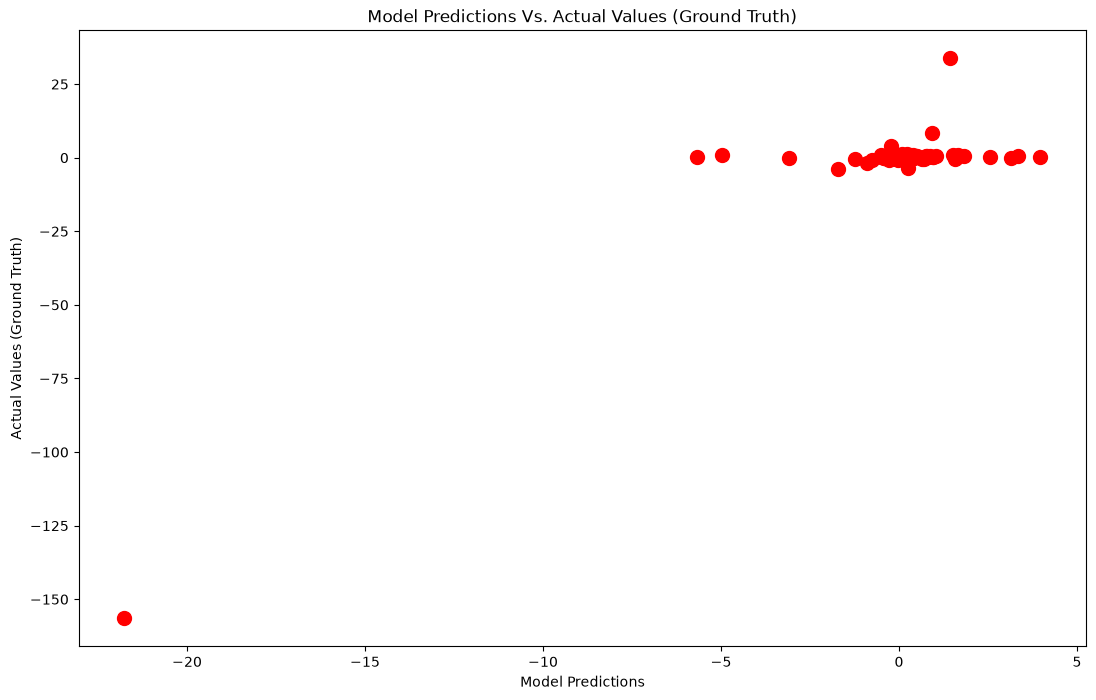

In [85]:
# Plot model predictions "y_predict" vs. actual outputs "y_test" (ground truth data)
plt.figure(figsize = (13, 8))
plt.plot(y_predict, y_test, 'o', color = 'r', markersize = 10)
plt.xlabel('Model Predictions')
plt.ylabel('Actual Values (Ground Truth)')
plt.title('Model Predictions Vs. Actual Values (Ground Truth)');

In [87]:
#PRACTICE OPPORTUNITY SOLUTION:** 
#Increase the maximum depth of the tree by setting max_depth = 100** 
# Retrain the Random Forest Regression model and evaluate its performance**

# Train a Random Forest Regression model with larger max_depth
# n_estimators: represents the number of trees in the forest
# max_depth: represents the maximum depth of the tree
random_forest_model = RandomForestRegressor(n_estimators = 5, max_depth = 100);
random_forest_model.fit(X_train, y_train);

In [89]:
#UNDERSTAND THE INTUITION BEHIND ARTIFICIAL NEURAL NETWORKS AND DEEP LEARNING (DL)

    #1 DL and Artificial Neural Networks
        # DL is a subfeld of ML that is inspired by the human brain and involves the training of Artificial Neural Networks with several layers of interconnected nodes, called artificial neurons, to learn from data and generate predictions
        # Biological neurons collect signals from input channels named dendrites, process information in their nucleus, and generate an output to the axon.
        # Artificial Neurons mimic the structure of biological neurons in which neurons are connected by pathways or weights that are adjusted during the training process to map input to output data.

    #2 Artificial Neuron Mathematical Model
        # the basic building block of ANNs is the artificial neuron which is called 'perceptron'
        # An artificial neuron takes in a set of inputs, applies a set of weights, add a bias b, applies an activation function f and produces a single output y
        # The activation function f is used to introduce non-linearity so the model can capture complex non-linear relationship between inputs and outputs. the bias b shifts the function curve up or down.

        #Artificial Neuron Example
            # assume I have an artificial neuron model with 3 inputs and a unit step activation function f.
            # the weight and bias values are W1= 0.8, W2=0.2, W3=0.5, b=0
            # the model received the following inputs : X1=2, X2=4, X3=6
            #y=f(X1*W1 + X2*W2 + X3*W3 + b)=f(5.4)
            #y=1 because 5.4>0
    #3 Multilayer Artificial Neural Networks
        #Multilayer Artificial Neural Networks (ANNs) consist of multiple layers of interconnected neurons.
        #ANNs consist of an input layer, one or more hidden layers, and an output layer.
        #The input layer receives the input data, and the output layer produces the final network predictions.
        #During ANNs training, our goal is to find the optimal values of weights (trainable parameters)

In [90]:
#TRAIN AND EVALUATE AN ARTIFICIAL NEURAL NETWORKS TO SOLVE REGRESSION PROBLEMS
#using Tensorflow and keras

#dens(fully connected) Layer
    # A dense layer is also known as a fully connected layer is one of the most commonly used layer in Artificial Neural Networks
    # In a dense, fully connected layer, each neuron in the layer takes input from all the neurons in the previous layer and calculates its output by applying a weighted sum of the inputs followed by applying an activation function

#Dropout
    #Dropout is a regularization technique used in Artificial Neural Networks training to prevent model overfitting to the training data.
    #During training, dropout randomly eliminates some of the nodes or connections in the neural network.




In [91]:
#train an Artifical Neural network to solve regression type problems using Tensorflow and Keras

!pip install tensorflow-cpu
import tensorflow as tf
from tensorflow import keras

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  Using cached wheel-0.48.0-py3-none-any.whl.metadata (2.3 kB)
   ---------------------------------------- 0.0/384.1 MB ? eta -:--:--
   ---------------------------------------- 2.9/384.1 MB 14.2 MB/s eta 0:00:27
   ---------------------------------------- 3.9/384.1 MB 9.9 MB/s eta 0:00:39
    --------------------------------------- 5.8/384.1 MB 9.3 MB/s eta 0:00:41
    --------------------------------------- 6.8/384.1 MB 8.2 MB/s eta 0:00:46
    --------------------------------------- 7.9/384.1 MB 7.6 MB/s eta 0:00:50
    --------------------------------------- 9.4/384.1 MB 7.6 MB/s eta 0:00:50
   - -------------------------------------- 11.8/384.1 MB 8.1 MB/s eta 0:00:47
   - -------------------------------------- 12.8/384.1 MB 7.7 MB/s eta 0:00:49
   - -------------------------------------- 14.9/384.1 MB 7.9 MB/s eta 0:00:47
   - -------------------------------------- 16.0/384.1 MB 7.8 MB/s eta 0:00:47
   - -------------------------------------- 17.3/384.1 MB 7.5 MB/s eta 0:00:50
  

In [92]:
# Let's perform input data scaling using MinMaxScaler() from Scikit-Learn library 
# Data scaling is an important pre-processing step in Artificial Neural Networks training 
# It improves model performance and speed up the training process
# Scaling works by normalizing features so they can have similar ranges and distributions so no feature dominates other features  
# Note that tree-based algorithms do not require data scaling
# MinMaxScaler scales the data to a range between 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler();
scaler.fit(X_train);

# Apply data scaling to the training and testing datasets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled

array([[0.03307404, 0.0349369 , 0.07935608, ..., 1.        , 0.        ,
        0.        ],
       [0.02161063, 0.02196776, 0.40567247, ..., 1.        , 0.        ,
        0.        ],
       [0.02188082, 0.02223556, 0.36385173, ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.03627761, 0.03784443, 0.12912159, ..., 0.        , 1.        ,
        0.        ],
       [0.03057293, 0.03208292, 0.04722144, ..., 0.        , 0.        ,
        1.        ],
       [0.83587991, 0.83231069, 0.36555677, ..., 1.        , 0.        ,
        0.        ]], shape=(323, 194))

In [93]:
#performing output data scaling
scaler = MinMaxScaler()
scaler.fit(pd.DataFrame(y_train))

#Apply data scaling to the training and testing datasets
y_train_scaled = scaler.transform(pd.DataFrame(y_train))
y_test_scaled = scaler.transform(pd.DataFrame(y_test))
X_train.shape[1]


194

In [94]:
#build ANN using Keras API

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Normalization, Dropout

ANN_model = Sequential()
ANN_model.add(Normalization(input_shape = [X_train.shape[1],], axis = None))
ANN_model.add(Dense(1024, activation = 'relu'))
ANN_model.add(Dropout(0.3))
ANN_model.add(Dense(512, activation = 'relu'))
ANN_model.add(Dropout(0.3))
ANN_model.add(Dense(256, activation = 'sigmoid'))
ANN_model.add(Dropout(0.3))
ANN_model.add(Dense(32, activation = 'sigmoid'))
ANN_model.add(Dropout(0.3))
ANN_model.add(Dense(units = 1, activation = 'linear'))

In [95]:
ANN_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 194)            │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       199,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 864,068 (3.30 MB)

 Trainable params: 864,065 (3.30 MB)

 Non-trainable params: 3 (16.00 B)

In [96]:
#we can compile the model by using Adam optimizer, because it can works well in DL applications and ANNs training
ANN_model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.00001), loss = 'mean_squared_error')

#fit the model using 100 epochs
history = ANN_model.fit(X_train_scaled, y_train_scaled, epochs = 100)


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 250ms/step - loss: 1.8599
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 1.7492
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 1.5789
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 1.4302
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 1.2902
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 1.1347
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.0755
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.0604
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.9574
Epoch 10/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.8863
Epoch 11/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.7802
Epoch 12/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 0.7378
Epoch 13/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.6548
Epoch 14/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.5816
Epoch 15/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - 

In [97]:
#generate model predictions using the testing dataset and then scale the data back to its original range values
y_predict_scaled = ANN_model.predict(X_test_scaled)
y_predict = scaler.inverse_transform(y_predict_scaled)
y_test = scaler.inverse_transform(y_test_scaled)

# Let's generate various regression metrics by comparing "y_predict" vs. actual outputs "y_test" (ground truth data)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np 

RMSE = float(np.sqrt(mean_squared_error(y_test, y_predict)))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)

print('Root Mean Squared Error (RMSE) =', RMSE, '\nMean Squared Error (MSE) =', MSE, '\nMean Absolute Error (MAE) =', MAE) 

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Root Mean Squared Error (RMSE) = 14.628766791220285 
Mean Squared Error (MSE) = 214.00081783190944 
Mean Absolute Error (MAE) = 7.348845570779385


''

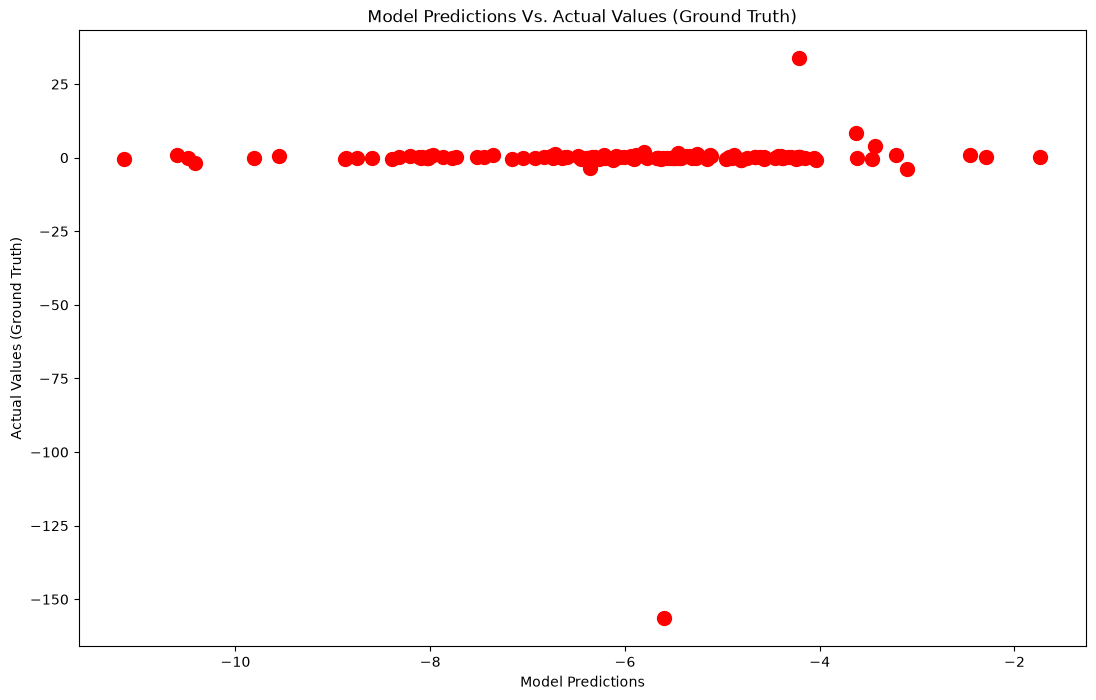

In [98]:
# Plot model predictions "y_predict" vs. actual outputs "y_test" (ground truth data)
plt.figure(figsize = (13, 8))
plt.plot(y_predict, y_test, 'o', color = 'r', markersize = 10)
plt.xlabel('Model Predictions')
plt.ylabel('Actual Values (Ground Truth)')
plt.title('Model Predictions Vs. Actual Values (Ground Truth)');''

In [99]:
#PRACTICE OPPORTUNITY:** 
# **Change the architecture of the existing Artificial Neural Network model by introducing an additional dense layer with Dropout. Feel free to choose the number of neurons.**
# **Print the model summary and list the number of trainable parameters**

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Normalization, Dropout

ANN_model = Sequential()
ANN_model.add(Normalization(input_shape = [X_train.shape[1],], axis = None))
ANN_model.add(Dense(1024, activation = 'relu'))
ANN_model.add(Dropout(0.3))
ANN_model.add(Dense(512, activation = 'relu'))
ANN_model.add(Dropout(0.3))
ANN_model.add(Dense(256, activation = 'sigmoid'))
ANN_model.add(Dropout(0.3))
ANN_model.add(Dense(256, activation = 'sigmoid')) # additional layer
ANN_model.add(Dropout(0.3))                       # additional layer
ANN_model.add(Dense(32, activation = 'sigmoid'))
ANN_model.add(Dropout(0.3))
ANN_model.add(Dense(units = 1, activation = 'sigmoid'))
ANN_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 194)            │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │       199,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929,860 (3.55 MB)

 Trainable params: 929,857 (3.55 MB)

 Non-trainable params: 3 (16.00 B)

In [100]:
#TRAIN AND EVALUATE AN XGBOOST MODEL
    #XGBoost (eXtreme Gradient Boosting) is a supervised ML technique that implements gradient boosted trees algorithm
    #XGBoost has gained wide popularity and become the go-to algorithm for many data scientists.
    #XGBoost works by building a series of models from the training data, each model is built to correct the mistakes made by the previous model. models are added sequently until no further improvement can be made

!pip install xgboost
import xgboost as xgb

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 2.7 MB/s eta 0:00:19
    --------------------------------------- 1.0/48.9 MB 2.8 MB/s eta 0:00:17
    --------------------------------------- 1.0/48.9 MB 2.8 MB/s eta 0:00:17
   - -------------------------------------- 1.3/48.9 MB 1.4 MB/s eta 0:00:34
   - -------------------------------------- 1.3/48.9 MB 1.4 MB/s eta 0:00:34
   - -------------------------------------- 1.6/48.9 MB 909.6 kB/s eta 0:00:53
   - -------------------------------------- 1.6/48.9 MB 909.6 kB/s eta 0:00:53
   - -------------------------------------- 1.6/48.9 MB 909.6 kB/s eta 0:00:53
   - -------------------------------------- 1.8/48.9 MB 744.6 kB/s eta 0:01:04
   - -------------------------------------- 2.1/48.9 MB 731.4 kB/s eta 0:01:05
   - -------------------------------------- 2.1/48.9 MB 731.4 kB/s eta 0:01:05
 

In [101]:
# Train an XGBoost regressor model 
xgb_model = xgb.XGBRegressor(objective ='reg:squarederror', 
                             learning_rate = 0.1, 
                             max_depth = 3, 
                             n_estimators = 200);
xgb_model.fit(X_train, y_train);

In [102]:
# Make predictions on the test data
y_predict = xgb_model.predict(X_test)
y_predict

array([-1.24097951e-02,  5.46474576e-01,  5.49698016e-03,  2.94851333e-01,
        9.97880697e-01,  9.83650506e-01, -1.06029403e+00,  3.35492313e-01,
       -9.95382518e-02,  3.83684738e-03, -2.45170379e+00,  1.31132230e-01,
        1.14391543e-01,  1.08711481e-01,  5.46821579e-02,  7.56379291e-02,
       -8.41683984e-01, -4.62904263e+00,  7.54694343e-02,  1.05538368e+00,
        1.94309935e-01,  3.59855711e-01,  1.74646258e+00,  2.37353832e-01,
        1.50524914e-01,  1.23526543e-01,  1.39987424e-01, -1.01839609e-01,
        3.51709574e-01,  8.36924016e-02,  1.38696343e-01,  1.11362539e-01,
        7.29039982e-02, -1.56356990e-01,  5.19607551e-02,  1.09861135e+00,
       -2.44947538e-01, -4.58920747e-03, -8.15320551e-01,  7.27902174e-01,
        2.43105024e-01,  9.77890193e-02, -3.62981558e-01,  1.30870000e-01,
       -4.02485847e-01,  3.28532606e-02, -9.98924375e-02,  7.51965702e-01,
        5.04722178e-01, -2.60613471e-01,  1.32093683e-01, -2.16640055e-01,
       -1.49349615e-01, -

In [103]:
#generate various regression metrics by comparing y_predict vs actual outputs y_test
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np 

RMSE = float(np.sqrt(mean_squared_error(y_test, y_predict)))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)

print('Root Mean Squared Error (RMSE) =', RMSE, '\nMean Squared Error (MSE) =', MSE, '\nMean Absolute Error (MAE) =', MAE) 

Root Mean Squared Error (RMSE) = 15.859809748207699 
Mean Squared Error (MSE) = 251.53356524934392 
Mean Absolute Error (MAE) = 2.2352504409670546


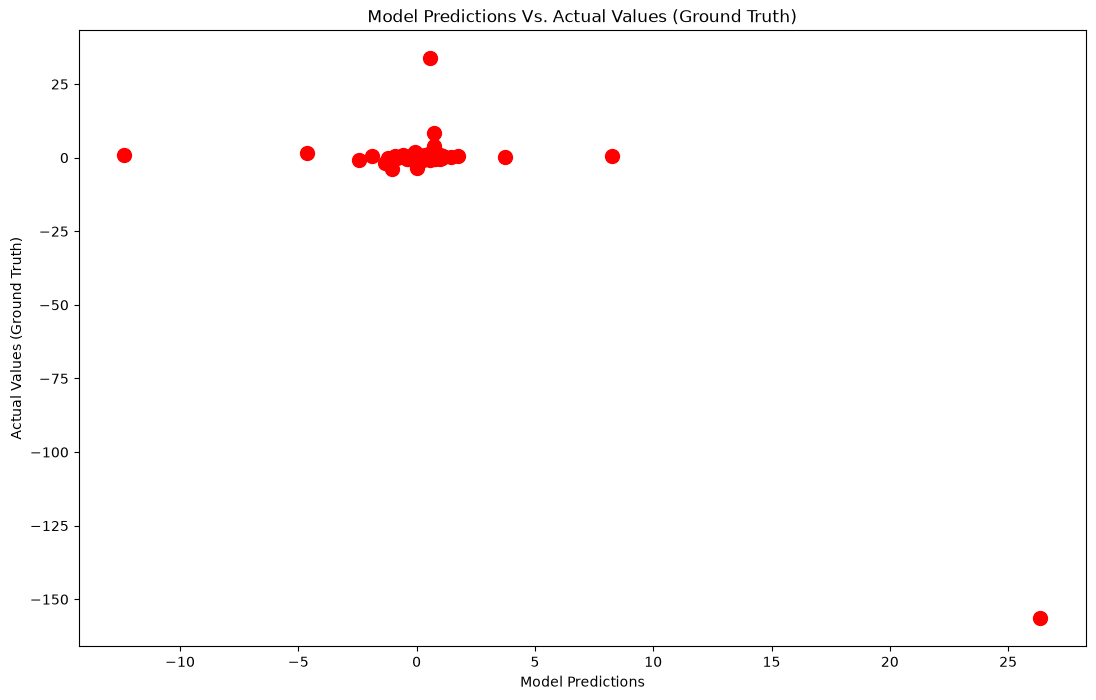

In [104]:
# Plot model predictions "y_predict" vs. actual outputs "y_test" (ground truth data)
plt.figure(figsize = (13, 8))
plt.plot(y_predict, y_test, 'o', color = 'r', markersize = 10)
plt.xlabel('Model Predictions')
plt.ylabel('Actual Values (Ground Truth)')
plt.title('Model Predictions Vs. Actual Values (Ground Truth)');

In [105]:
#PRACTICE OPPORTUNITY:**
# **Set the max_depth hyperparameter to 1 and retrain the XGBoost model**
# **Calculate regression metrics and comment on the results**

# Train an XGBoost regressor model 
xgb_model = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.1, max_depth = 1, n_estimators = 100)
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_predict = xgb_model.predict(X_test)


RMSE = float(np.sqrt(mean_squared_error(y_test, y_predict)))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)

print('Root Mean Squared Error (RMSE) =', RMSE, '\nMean Squared Error (MSE) =', MSE, '\nMean Absolute Error (MAE) =', MAE) 

Root Mean Squared Error (RMSE) = 16.790038670948753 
Mean Squared Error (MSE) = 281.9053985719546 
Mean Absolute Error (MAE) = 2.5541179644798926


In [106]:
#PERFORM HYPERPARAMETERS OPTIMIZATION
#GridSearchCV performs exhaustive search over a specified list of parameters

# GridSearchCV performs exhaustive search over a specified list of parameters
# You provide the algorithm with the hyperparameters and values you would like to experiment with 
# Note that you will have the following number of combinations: 4 * 4 * 4 * 3 = 192
# We will run each combination 5 times since we set the cross validation = 5
# Total number of runs = 192 * 5 = 960 fits

from sklearn.model_selection import GridSearchCV

In [107]:
# Specify the parameters grid
parameters_grid = {'max_depth': [1, 3, 5, 10],
                   'learning_rate': [0.01, 0.1, 0.5, 1],
                   'n_estimators': [10, 50, 100, 200],
                   'subsample': [0.5, 0.75, 1.0]} 

In [108]:
#neg_mean_squared_error is used for scoring since our goal is to minimize the error
#GridSearchCV() ranks all algorithms (estimators) and specifies which one is the best
#cv stands for the number of cross-validation folds which is set to 5 by default
#verbose controls the verbosity: the higher the number, the more messages to be displayed

xgb_gridsearch = GridSearchCV(estimator = xgb.XGBRegressor(objective = 'reg:squarederror'), 
                              param_grid = parameters_grid, 
                              scoring = 'neg_mean_squared_error',  
                              cv = 5, 
                              verbose = 5)


In [109]:
#to fit the model
xgb_gridsearch.fit(X_train, y_train);

Fitting 5 folds for each of 192 candidates, totalling 960 fits
[CV 1/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.5;, score=-1.016 total time=   0.2s
[CV 2/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.5;, score=-24.274 total time=   0.1s
[CV 3/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.5;, score=-38.769 total time=   0.2s
[CV 4/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.5;, score=-15.186 total time=   4.2s
[CV 5/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.5;, score=-0.389 total time=   0.0s
[CV 1/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.75;, score=-1.008 total time=   0.0s
[CV 2/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.75;, score=-24.213 total time=   0.1s
[CV 3/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.75;, score=-38.547 total time=   0.0s
[CV 4/5] END learning_rate=0.01, max_dept

In [110]:
#to indicate best parameters after grid search optimization
xgb_gridsearch.best_params_

{'learning_rate': 0.01, 'max_depth': 1, 'n_estimators': 10, 'subsample': 1.0}

In [111]:
#Display the best estimator values
xgb_gridsearch.best_estimator_

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [112]:
# Generate predictions based on the optimal model parameters
y_predict = xgb_gridsearch.predict(X_test)
y_predict

array([0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519169,
       0.11519169, 0.11519169, 0.11519169, 0.11519169, 0.11519

In [113]:
#generate various regression metrics by comparing y_predict vs actual output y_test
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np 

RMSE = float(np.sqrt(mean_squared_error(y_test, y_predict)))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)

print('Root Mean Squared Error (RMSE) =', RMSE, '\nMean Squared Error (MSE) =', MSE, '\nMean Absolute Error (MAE) =', MAE) 

Root Mean Squared Error (RMSE) = 13.82135884039318 
Mean Squared Error (MSE) = 191.02996019491474 
Mean Absolute Error (MAE) = 1.8568056503668828


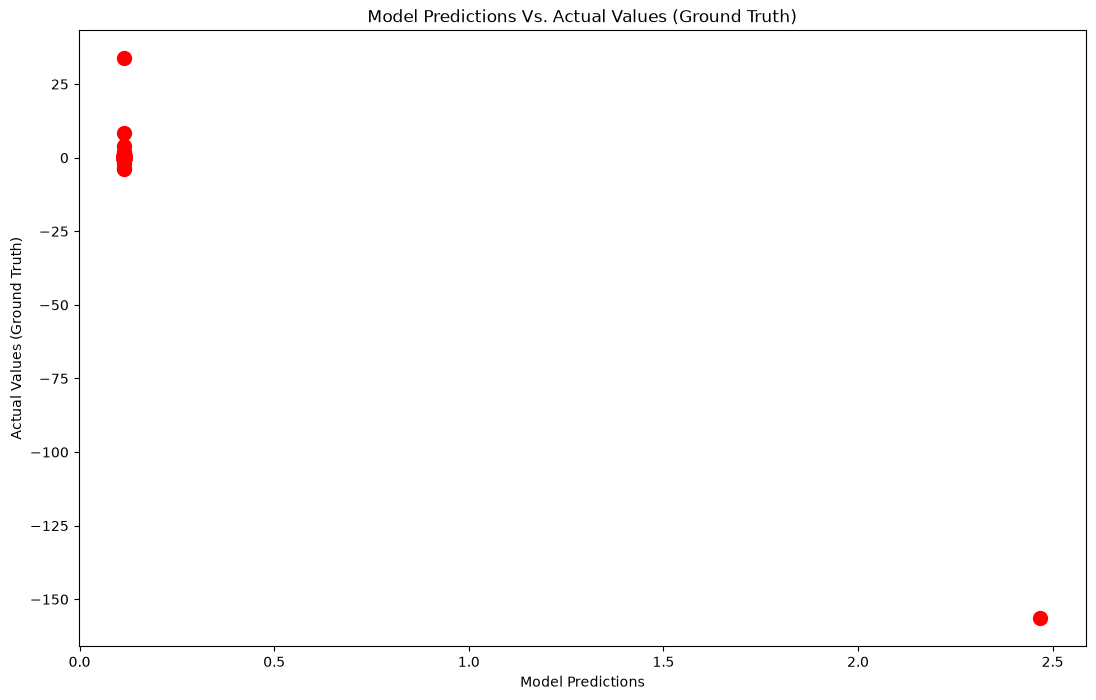

In [114]:
# Plot model predictions "y_predict" vs. actual outputs "y_test" (ground truth data)
plt.figure(figsize = (13, 8))
plt.plot(y_predict, y_test, 'o', color = 'r', markersize = 10)
plt.xlabel('Model Predictions')
plt.ylabel('Actual Values (Ground Truth)')
plt.title('Model Predictions Vs. Actual Values (Ground Truth)');

In [115]:
#PRACTICE OPPORTUNITY:**
# **Train and evaluate an XGBoost algorithm to predict the percentage quarterly change in revenue instead of the percentage quarterly change in EPS. Note that this target variable is available in the original dataset and titled "% Change in Quarterly Revenue (Target Output)".**
# **Perform hyperparameters tuning and evaluate trained model performance and comment on the results.**

df = pd.read_csv(r"C:\Users\shann\AppData\Local\Programs\Microsoft VS Code\financial_data.csv")

apple_df= df[df['Ticker']== 'AAPL']
apple_df

,Company Name,Sector,Industry,Ticker,Report Date,Currency,Fiscal Year,Fiscal Period,Publish Date,Restated Date,Shares (Basic),Shares (Diluted),Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Operating Income (Loss),Non-Operating Income (Loss),"Interest Expense, Net","Pretax Income (Loss), Adj.",Pretax Income (Loss),"Income Tax (Expense) Benefit, Net",Income (Loss) from Continuing Operations,Net Income,Net Income (Common),Net Income/Starting Line,Non-Cash Items,Change in Working Capital,Net Cash from Operating Activities,Change in Fixed Assets & Intangibles,Net Cash from Investing Activities,Dividends Paid,Cash from (Repayment of) Debt,Cash from (Repurchase of) Equity,Net Cash from Financing Activities,Net Change in Cash,"Cash, Cash Equivalents & Short Term Investments",Cash & Cash Equivalents,Accounts & Notes Receivable,"Accounts Receivable, Net",Inventories,Other Short Term Assets,Misc. Short Term Assets,Total Current Assets,"Property, Plant & Equipment, Net",Other Long Term Assets,Goodwill,Misc. Long Term Assets,Total Noncurrent Assets,Total Assets,Payables & Accruals,Accounts Payable,Other Payables & Accruals,Short Term Debt,Other Short Term Liabilities,Total Current Liabilities,Long Term Debt,Other Long Term Liabilities,Misc. Long Term Liabilities,Total Noncurrent Liabilities,Total Liabilities,Share Capital & Additional Paid-In Capital,Retained Earnings,Other Equity,Equity Before Minority Interest,Total Equity,Total Liabilities & Equity,EBITDA,Total Debt,Free Cash Flow,Gross Profit Margin,Operating Margin,Net Profit Margin,Return on Equity,Return on Assets,Free Cash Flow to Net Income,Current Ratio,Liabilities to Equity Ratio,Debt Ratio,"Earnings Per Share, Basic","Earnings Per Share, Diluted",Sales Per Share,Equity Per Share,Free Cash Flow Per Share,Dividends Per Share,Piotroski F-Score,Return On Invested Capital,Cash Return On Invested Capital,Dividend Payout Ratio,Net Debt / EBITDA,Net Debt / EBIT,Shares (Basic) change from last quarter,Shares (Basic) change from last 2 quarters,Shares (Basic) change from last 3 quarters,Shares (Basic) change from last 4 quarters,Shares (Diluted) change from last quarter,Shares (Diluted) change from last 2 quarters,Shares (Diluted) change from last 3 quarters,Shares (Diluted) change from last 4 quarters,Revenue change from last quarter,Revenue change from last 2 quarters,Revenue change from last 3 quarters,Revenue change from last 4 quarters,Operating Income (Loss) change from last quarter,Operating Income (Loss) change from last 2 quarters,Operating Income (Loss) change from last 3 quarters,Operating Income (Loss) change from last 4 quarters,Net Income change from last quarter,Net Income change from last 2 quarters,Net Income change from last 3 quarters,Net Income change from last 4 quarters,Total Assets change from last quarter,Total Assets change from last 2 quarters,Total Assets change from last 3 quarters,Total Assets change from last 4 quarters,Total Liabilities & Equity change from last quarter,Total Liabilities & Equity change from last 2 quarters,Total Liabilities & Equity change from last 3 quarters,Total Liabilities & Equity change from last 4 quarters,EBITDA change from last quarter,EBITDA change from last 2 quarters,EBITDA change from last 3 quarters,EBITDA change from last 4 quarters,Free Cash Flow change from last quarter,Free Cash Flow change from last 2 quarters,Free Cash Flow change from last 3 quarters,Free Cash Flow change from last 4 quarters,Gross Profit Margin change from last quarter,Gross Profit Margin change from last 2 quarters,Gross Profit Margin change from last 3 quarters,Gross Profit Margin change from last 4 quarters,Operating Margin change from last quarter,Operating Margin change from last 2 quarters,Operating Margin change from last 3 quarters,Operating Margin change from last 4 quarters,Net Profit Margin change from last quarter,Net Profit Margin change from last 2 quarters,Net Profit Margin change from last

In [116]:
# Drop the following columns from the Pandas DataFrame
cols_to_drop = ['Ticker','Sector', 'Industry','Company Name', 'Report Date', 'Currency',
                'Fiscal Year', 'Publish Date', 'Restated Date', '% Change in Quarterly EPS (Target Output)']

apple_df = apple_df.drop(columns = cols_to_drop)

#display the one hot encoded version of the fiscal period column

fiscal_encoded = pd.get_dummies(apple_df['Fiscal Period'])

# Drop the 'Fiscal Period' column from the Pandas DataFrame
apple_df = apple_df.drop('Fiscal Period', axis = 1)

# Concatenate the original DataFrame and the one hot encoded "Fiscal Period" column
apple_df = pd.concat([apple_df, fiscal_encoded], axis = 1)

# Split the data into input (X) and output (y)
X = apple_df.drop('% Change in Quarterly Revenue (Target Output)', axis = 1)
y = apple_df['% Change in Quarterly Revenue (Target Output)']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, shuffle = False)


In [117]:
# Train an XGBoost regressor model 
xgb_model = xgb.XGBRegressor(objective ='reg:squarederror', learning_rate = 0.1, max_depth = 1, n_estimators = 50, subsample = 1.0);
xgb_model.fit(X_train, y_train);

# Make predictions on the test data
y_predict = xgb_model.predict(X_test)
y_predict

array([-0.04627109,  0.06140716,  0.46143115, -0.1916395 , -0.04925757,
       -0.00669827,  0.521327  , -0.11693041,  0.02563882,  0.11180957,
        0.3883295 , -0.17640035,  0.02563882,  0.049413  ,  0.3092044 ,
       -0.16033891, -0.09016649, -0.00640846,  0.46236262, -0.17357416,
       -0.0832679 ,  0.01352938], dtype=float32)

In [118]:
#generate various regression metrics by comparing y_predict vs actual output y_test
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np 

RMSE = float(np.sqrt(mean_squared_error(y_test, y_predict)))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)

print('Root Mean Squared Error (RMSE) =', RMSE, '\nMean Squared Error (MSE) =', MSE, '\nMean Absolute Error (MAE) =', MAE) 

Root Mean Squared Error (RMSE) = 0.13993814171398547 
Mean Squared Error (MSE) = 0.019582683506363482 
Mean Absolute Error (MAE) = 0.1044840737088527


In [119]:
# Specify the parameters grid
parameters_grid = {'max_depth': [1, 3, 5, 10],
                   'learning_rate': [0.01, 0.1, 0.5, 1],
                   'n_estimators': [10, 50, 100, 200],
                   'subsample': [0.5, 0.75, 1.0]} 

In [120]:
xgb_gridsearch = GridSearchCV(estimator = xgb.XGBRegressor(objective = 'reg:squarederror'), 
                              param_grid = parameters_grid, 
                              scoring = 'neg_mean_squared_error',  
                              cv = 5, 
                              verbose = 5)

In [121]:
xgb_gridsearch.fit(X_train, y_train);

Fitting 5 folds for each of 192 candidates, totalling 960 fits
[CV 1/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.5;, score=-0.009 total time=   0.2s
[CV 2/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.5;, score=-0.074 total time=   0.2s
[CV 3/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.5;, score=-0.046 total time=   0.1s
[CV 4/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.5;, score=-0.082 total time=   0.1s
[CV 5/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.5;, score=-0.125 total time=   0.1s
[CV 1/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.75;, score=-0.009 total time=   0.1s
[CV 2/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.75;, score=-0.072 total time=   0.0s
[CV 3/5] END learning_rate=0.01, max_depth=1, n_estimators=10, subsample=0.75;, score=-0.046 total time=   0.0s
[CV 4/5] END learning_rate=0.01, max_depth=1, 

In [122]:
# Generate predictions based on the optimal model parameters
y_predict = xgb_gridsearch.predict(X_test)
y_predict

array([-0.12655605,  0.07020825,  0.5649192 , -0.3352421 , -0.03629845,
        0.04722596,  0.48076227, -0.29745147, -0.04227684, -0.00234895,
        0.31938422, -0.25011784, -0.09653547,  0.03564352,  0.39151236,
       -0.20160338, -0.1514454 ,  0.00336153,  0.41151354, -0.27126864,
       -0.09193866,  0.018478  ], dtype=float32)

In [123]:
#generate various regression metrics by comparing y_predict vs actual output y_test
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np 

RMSE = float(np.sqrt(mean_squared_error(y_test, y_predict)))
MSE = mean_squared_error(y_test, y_predict)
MAE = mean_absolute_error(y_test, y_predict)

print('Root Mean Squared Error (RMSE) =', RMSE, '\nMean Squared Error (MSE) =', MSE, '\nMean Absolute Error (MAE) =', MAE) 

Root Mean Squared Error (RMSE) = 0.1126554798278433 
Mean Squared Error (MSE) = 0.012691257135241607 
Mean Absolute Error (MAE) = 0.08718300017593399
